# micrograd 
----
* 灵感来源于 Andrej Karpathy 的教程：["The spelled-out intro to neural networks & backpropagation: building micrograd"](https://www.youtube.com/watch?v=VMj-3S1tku0&t=4822s)

* 用于课后巩固练习的 *micrograd* 习题可以在 Andrej Karpathy 提供的这个 [Colab Notebook](https://colab.research.google.com/drive/1FPTx1RXtBfc4MaTkf7viZZD4U2F9gtKN?usp=sharing) 中找到。


# 目录
------------------
- [0. 引言](#0)<br>
    - [0.1. 导数概述](#001)
- [1. Micrograd: 自动求导引擎](#1)
- [2. Micrograd: DAG 计算图可视化](#2)
- [3. Micrograd: 反向传播](#3)
    - [3.1. 手动反向传播示例 001：简单数学表达式](#301)
    - [3.2. 单步优化预览](#302)
- [4. Micrograd: 神经元](#4)
    - [4.1. 生物神经元 vs. 人工神经元](#401)
    - [4.2. 感知机](#402)
    - [4.3. 激活函数](#403)
    - [4.4. 手动反向传播示例 002：单个神经元](#404)
- [5. Micrograd: 为每个运算实现 Backward 反向求导函数](#5)
- [6. Micrograd: 修复同一个节点被多次使用时的反向传播 Bug](#6)
    - [6.1. 多元微积分链式法则](#601)
- [7. Micrograd: 添加更多数学运算](#7)
    - [7.1. 将 `tanh` 函数分解为其基本组成部分](#701)
- [8. Micrograd: 与 `PyTorch` 的对比验证](#8)
- [9. Micrograd: 构建神经网络库（多层感知机 MLP）](#9)
    - [9.1. 神经网络架构](#901)
- [10. Micrograd: 创建微型数据集并编写损失函数](#10)
- [11. Micrograd: 神经网络参数](#11)
- [12. Micrograd: 手动梯度下降优化与训练 MLP](#12)
- [13. Micrograd: 总结](#13)



# 附录
---------------
## 图表
- [A1. 从左至右：生物神经元示意图与其数学模型。](#a1)
- [A2. 单层感知机结构。](#a2)
- [A3. 拓扑排序。](#a3)
- [A4. 从左至右：两个多层感知机（MLP）示意图：2 层神经网络与 3 层神经网络。](#a4)


## 表格
- [B1. 激活函数](#b1)

## 公式
- [C1. 函数 f(x) 在 x 处可导的数学定义](#c1)
- [C2. 神经网络加权求和函数的数学表示](#c2)
- [C3. 多元函数链式法则：示例](#c3)
- [C4. 均方误差（MSE）](#c4)


## 核心定义
- [1. 反向传播 (backpropagation)](#d1)
- [2. micrograd](#d2)
- [3. 梯度下降 (gradient descent)](#d3)


## [参考文献](#r1)


-----------
<br><br>
# 0. 引言<a id="0"></a>
---------------------------------
这是关于反向传播和神经网络训练最详尽、最循序渐进的透彻解析。本教程仅假定你具备基础的 Python 编程知识，以及对高中微积分的模糊记忆。

本教程涵盖了神经网络（NN）基本运作机制的入门介绍。神经网络在图像分类、文本序列识别等诸多应用中极为常见。我们将深入探讨关于神经网络的几个基本问题：
1. 什么是神经网络？
    - 神经网络是具有输入和输出的数学函数/计算表达式。
2. “训练”神经网络意味着什么？
    - 意味着通过调整神经网络模型的参数来最小化损失函数，从而使模型的预测值尽可能接近目标真实值（ground truth）。
3. 我们如何调整/控制神经网络？
    - 这就轮到反向传播算法登场了，它是训练神经网络的核心基石。

我们将从零构建一个微型自动求导引擎 **Micrograd**，以此来深入学习并理解神经网络与反向传播的本质。


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 0.1. 导数概述<a id="001"></a>
------
让我们先定义一个简单的函数并绘制它的图像。


In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

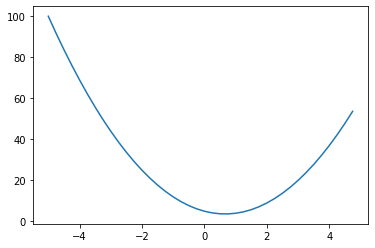

In [6]:
plt.plot(xs, ys)
plt.show()

我们希望计算函数在各个点上的导数。在这个示例中，我们可以直接显式地算出函数的导数解析式。然而，当面对复杂的神经网络时，这种手工求显式解析式的方法并不可行。那么，什么是导数？<br> 

从本质上讲，导数的直观含义如下：

*“假设我有一个依赖于变量 x 的函数 y。如果我在某个点将 x 微调一丁点，那么作为响应，y 的变化率会是多少？”*

<u>几何与直观解释</u>：导数表示在特定点附近的无穷小区域内，函数相对于该自变量的变化率：

数学上，[导数](https://en.wikipedia.org/wiki/Derivative)的定义如下所示：
<a id="c1"></a>
![函数 f(x) 在 x 处可导的数学定义](_imgs/differentiable_function.png)<br>
**公式 1: 函数 f(x) 在 x 处可导的数学定义。** ([来源](https://cs231n.github.io/optimization-2/))<br>


我们给自变量 x 一个微小的扰动，并观察函数的响应变化。在公式 1 中，我们通过将 `f(x+h)`（将 `f(x)` 微调极小量 `h` 得到）与 `f(x)` 的差值除以扰动量 `h`，来计算变化率。导数刻画了函数对其输入变量变化的敏感程度（sensitivity）。下面我们将对导数进行简单的数值逼近。


In [7]:
h = 0.00000001
x = 3.0
(f(x + h) - f(x))/h

14.00000009255109

In [8]:
h = 0.00000001
x = -3.0
(f(x + h) - f(x))/h

-22.00000039920269

In [9]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

如上所示，随着我们选取的 h 值越来越小，计算出的数值梯度分别收敛到在 **x = 3、-3 和 2/3** 处的真实梯度 **14、-22 和 0**。如果 h 的值无限接近于 0，数值导数就会精确等于解析导数。<br>
在极值点（**x = 2/3**）处，梯度为 0！在该点改变输入，函数在局部不会产生任何一阶变化。<br><br>
假设我们有多个输入变量。接下来让我们计算 `d` 关于 `c` 的导数。


In [10]:
# 尝试更复杂的表达式
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [11]:
h = 0.0001

# 输入变量
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)
      

d1 4.0
d2 4.0001
slope 0.9999999999976694


由于 **c** 在这里的线性组合中系数为 1，对 **c** 进行极小变化（*h*）将导致 **d** 产生完全相同的变化量。因此，梯度/导数为 **1**。我们可以对 **a** 和 **b** 进行同样的操作，来分析 **d** 是如何随之变化的。

接下来，让我们讨论 Micrograd 及其创建、实现与管理。为了构建神经网络并利用 Micrograd 引擎，我们需要设计专门的数据结构。


---------
<br><br>
# 1. Micrograd: 自动求导引擎<a id="1"></a>
-------------------------------------------------------
<a id="d2"></a>
<u>Micrograd:</u> 一个微型**自动求导** (autograd / 自动微分) 引擎，它在动态构建的**有向无环图 (DAG)** 上实现**反向传播**（反向模式自动微分），并在其之上封装了一个具有类似 **PyTorch 风格 API** 的**小型神经网络库**。这是一个标量级别的自动求导引擎。这两个 Python 对象（DAG 计算图与神经网络库）都极其轻量，分别仅约 100 行和 50 行代码。DAG 仅在标量值上运算，例如我们将每个神经元拆解为最微小的单个加法和乘法运算。然而，正如下面的演示 Notebook 所示，这已经足以搭建出执行二分类任务的完整深度神经网络。<br><br>
构建 **micrograd** 的核心目标：
1. 教学与启发目的
2. 彻底理解神经网络（NNs）
3. 深入理解反向传播（链式法则与求导）
4. 理解标量运算与张量（Tensor）运算在数学本质上是一致的<br>
    a. 计算机通过并行化处理张量（标量数组）<br>
    b. 使用张量大幅提高计算效率
5. 掌握训练神经网络所需的核心底层机制

在本 Notebook 中，我们将用 Python 从零构建 Micrograd —— 一个极简的自动微分（**autodiff**）引擎。自动微分/自动求导算法构成了诸如 `PyTorch` 和 `TensorFlow` 等现代深度学习框架的基础，其工作原理是在计算图（如神经网络等 DAG）中自动计算梯度。本教程灵感源自 Andrej Karpathy 的 [Neural Networks: Zero to Hero](https://karpathy.ai/zero-to-hero.html) 系列讲座中的 <u>"The spelled-out intro to neural networks and backpropagation: building micrograd"</u>。Andrej Karpathy 的 Micrograd 完整版本可以在 [GitHub](https://github.com/karpathy/micrograd) 上找到。

我们首先需要做的是构思一种在 Python 中表示数值和数学运算的方法，以便能够完成各种计算并追踪依赖关系。本质上，我们需要一个简单而稳健的数据结构，作为 Micrograd 引擎的基础积木和连接纽带。

让我们开发一个基础数据结构（核心 `Value` 类）来管理 micrograd 的计算。


In [12]:
class Value:
    """ 存储单个标量数值及其对应的梯度 """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        # 用于自动求导计算图构建的内部变量
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # 生成该节点的运算操作符，用于 Graphviz 可视化 / 调试等
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def exp(self):
        x = self.data
        t = math.exp(x)
        out = Value(t, (self,), 'exp')
        
        def _backward():
            self.grad += t * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        
        # 构建 DAG 中所有子节点的拓扑排序列表
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
 
        # 根据反向传播的要求，必须逆序遍历拓扑排序列表
        # 逐个遍历变量并应用链式法则计算其梯度
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1


In [13]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

e = a*b; e.label ='e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'
L

Value(data=-8.0, grad=0.0)

In [14]:
print(f"The input nodes of L are {L._prev}")
print(f"The label of L is {L.label}")

The input nodes of L are {Value(data=4.0, grad=0.0), Value(data=-2.0, grad=0.0)}
The label of L is L


In [15]:
L._op

'*'

---------
<br><br>
# 2. Micrograd: DAG 计算图可视化<a id="2"></a>
-------------------------------------------------------
在这一部分，我们使用两个 Python 库（`Graphviz` 和 `Trace`）来将计算图（DAG）可视化。可视化对于直观理解数学表达式在有向无环图中的组织方式非常有帮助。

Graphviz 是一个开源的图形可视化软件。图可视化是一种将结构信息表示为抽象图形和网络图解的方法。它在软件工程、生物信息学、网络分析、数据库设计以及机器学习中都有着广泛应用。


我们需要安装 Graphviz 才能使用可视化工具。我们将定义两个函数 `trace` 和 `draw_dot` 来绘制 DAG 图。


In [16]:
import sys
print(sys.executable)

/Users/CEO/anaconda3/envs/py36/bin/python


In [17]:
import graphviz
graphviz.__version__, graphviz.version()

('0.19.1', (10, 0, 1))

In [18]:
from graphviz import Digraph

def trace(root):
    """
    构建计算图中所有节点和边的集合
    """
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = 从左至右布局 (left to right)
    nodes, edges = trace(root)    
    for n in nodes:
        uid = str(id(n))
        # 为图中的每个 Value 节点创建一个矩形（'record'）节点
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # 如果该 Value 是某种运算的结果，则为其创建一个运算节点
            dot.node(name = uid + n._op, label=n._op)
            # 并将运算节点连接到该 Value 节点
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # 将输入节点 n1 连接到 n2 的运算节点
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

我们创建了两个辅助函数：
- `trace`: 该函数通过递归构建并存储计算图中所有节点和边的集合。
- `draw_dot`: 该函数接收一个 `Value` 对象，并借助 Graphviz 库构建出计算图的树状图/网络图。

现在我们可以将之前构建的数学表达式可视化了。


-------------
<br><br>
# 3. Micrograd: 反向传播<a id="3"></a>
---------------------------------
<a id="d1"></a>
**反向传播 (Backpropagation)** 的普适性远不止于神经网络 (NN)。它是一种在计算图上递归应用微积分链式法则以计算梯度的通用算法。它是用于训练人工神经网络（ANNs）最广泛的技术之一。

简而言之，反向传播算法的工作流程是：计算损失函数关于神经网络中各个权重的梯度（偏导数），对于单个输入输出样本逐层反向传播该梯度误差。

在这一部分，我们将为计算图中的每个中间节点和叶子节点手动计算导数（梯度），并将每个结果填入各节点对应的 `grad` 变量中。我们将从输出节点开始，向后遍历到输入节点，并在每个节点处应用链式法则。

为了计算任意节点的导数，我们需要求出最终输出变量（这里记为 `L`）关于当前变量的导数。我们将通过几个手动计算反向传播梯度的示例来进行演练。


-------------
<br><br>
## 3.1. 手动反向传播示例 001：简单数学表达式<a id="301"></a>
-------------------------------------------------------
在反向传播中，我们<u>递归地应用微积分的链式法则</u>。让我们先对下面的简单数学表达式进行手动反向传播计算。我们将计算输出 `L` 关于该表达式中所有变量（节点）的导数：


计算函数表达式：

\begin{align*}
a & = 2.0, \quad b = -3.0, \quad c = 10.0, \quad f = -2.0 \\
e & = a \cdot b \\
d & = e + c \\
L & = d \cdot f = 8.0 \\
\end{align*}

\begin{align*}
(a, b) & \rightarrow e \\
(e, c) & \rightarrow d \\
(d, f) & \rightarrow L \\
\end{align*}

根据微积分链式法则求各节点的偏导数：

\begin{align*}
\frac{dL}{dL} & = 1.0 \\
\frac{dL}{dd} & = f = -2.0 \\
\frac{dL}{df} & = d = -4.0 \\
\frac{dL}{dc} & = \frac{dL}{dd} \cdot \frac{dd}{dc} = -2.0 \cdot 1.0 = -2.0 \\
\frac{dL}{de} & = \frac{dL}{dd} \cdot \frac{dd}{de} = -2.0 \cdot 1.0 = -2.0 \\
\frac{dL}{da} & = \frac{dL}{de} \cdot \frac{de}{da} = -2.0 \cdot b = -2.0 \cdot -3.0 = 6.0 \\
\frac{dL}{db} & = \frac{dL}{de} \cdot \frac{de}{db} = -2.0 \cdot a = -2.0 \cdot 2.0 = -4.0 \\
\end{align*}


In [19]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

e = a*b; e.label ='e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'
L

Value(data=-8.0, grad=0.0)

In [20]:
L.grad = 1.0                  # dL/dL
f.grad = d.data               # dL/df
d.grad = f.data               # dL/dd
c.grad = e.grad = d.grad      # dL/dc, dL/de
a.grad = e.grad * b.data      # dL/da
b.grad = e.grad * a.data      # dL/db

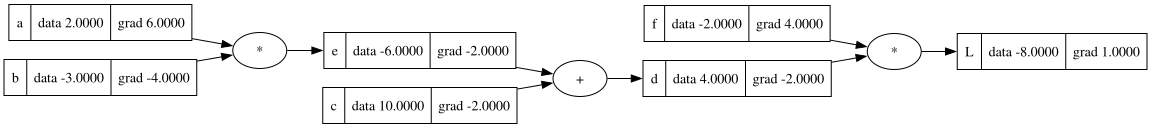

In [21]:
draw_dot(L)

----
下面的 `grad_check` 函数用于分析参数（`输入: var`）的变化如何引起输出的响应。它本质上通过数值微商给出了 L 关于每个参数的斜率（梯度）。我们可以用它来验证前面手动计算的符号梯度是否准确。


In [22]:
def grad_check(var, h=0.001): # 内联梯度数值校验
    """
    parameters:
    
    var {string} : a,b,c,d,e,f
    h {float}: step change
    
    adjust a,b,c,d,e,f by h and see how it affects L 
    estimate dL/di, where i =  a,b,c,d,e,f
    """
    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a*b; e.label ='e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L1 = L.data
    
    if var=='a':
        a = Value(2.0,label='a')
        a.data += h
        b = Value(-3.0,label='b')
        c = Value(10.0,label='c')
        e = a*b; e.label ='e'
        d = e+c; d.label = 'd'
        f = Value(-2.0, label='f')
        L = d * f 
        L.label = 'L'
        L2 = L.data
    elif var=='b':
        a = Value(2.0,label='a')
        b = Value(-3.0,label='b')
        b.data += h
        c = Value(10.0,label='c')
        e = a*b; e.label ='e'
        d = e+c; d.label = 'd'
        f = Value(-2.0, label='f')
        L = d * f 
        L.label = 'L'
        L2 = L.data
    elif var=='c':
        a = Value(2.0,label='a')
        b = Value(-3.0,label='b')
        c = Value(10.0,label='c')
        c.data += h
        e = a*b; e.label ='e'
        d = e+c; d.label = 'd'
        f = Value(-2.0, label='f')
        L = d * f 
        L.label = 'L'
        L2 = L.data
    elif var=='d':
        a = Value(2.0,label='a')
        b = Value(-3.0,label='b')
        c = Value(10.0,label='c')
        e = a*b; e.label ='e'
        d = e+c; d.label = 'd'
        d.data += h
        f = Value(-2.0, label='f')
        L = d * f 
        L.label = 'L'
        L2 = L.data
    elif var=='e':
        a = Value(2.0,label='a')
        b = Value(-3.0,label='b')
        c = Value(10.0,label='c')
        e = a*b; e.label ='e'
        e.data += h
        d = e+c; d.label = 'd'
        f = Value(-2.0, label='f')
        L = d * f
        L.label = 'L'
        L2 = L.data
    elif var=='f':
        a = Value(2.0,label='a')
        b = Value(-3.0,label='b')
        c = Value(10.0,label='c')
        e = a*b; e.label ='e'
        d = e+c; d.label = 'd'
        f = Value(-2.0, label='f')
        f.data += h
        L = d * f
        L.label = 'L'
        L2 = L.data
    elif var=='L':
        a = Value(2.0,label='a')
        b = Value(-3.0,label='b')
        c = Value(10.0,label='c')
        e = a*b; e.label ='e'
        d = e+c; d.label = 'd'
        f = Value(-2.0, label='f')
        L = d * f
        L.data += h
        L.label = 'L'
        L2 = L.data
    else:
        print("The variable is NOT recognized !!! Ensure its one of these (case-sensitive): a, b, c, d, e, f, L")
        return None
    
    return (L2 - L1)/h

In [23]:
print(f"dL/dL = {grad_check('L'):.3f}")
print(f"dL/dd = {grad_check('d'):.3f}")
print(f"dL/df = {grad_check('f'):.3f}")
print(f"dL/dc = {grad_check('c'):.3f}")
print(f"dL/de = {grad_check('e'):.3f}")
print(f"dL/da = {grad_check('a'):.3f}")
print(f"dL/db = {grad_check('b'):.3f}")

dL/dL = 1.000
dL/dd = -2.000
dL/df = 4.000
dL/dc = -2.000
dL/de = -2.000
dL/da = 6.000
dL/db = -4.000


In [24]:
grad_check('df')

The variable is NOT recognized !!! Ensure its one of these (case-sensitive): a, b, c, d, e, f, L


-------------
<br><br>
## 3.2. 单步优化预览<a id="302"></a>
-------------------------------------------------------
如果我们沿着变量梯度的方向微调变量（使 L 增大），这就是**优化 (Optimization)** 的核心思想。让我们来试一下。

目前 L = -8.0000。让我们沿着梯度的方向调整输入变量。


In [25]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b 
d = e + c
L = d * f

print(L.data)

-7.286496


在执行前向传播后，`L = -7.286`。这里 0.01 是步长（学习率）。我们确实看到，在利用手动计算的梯度优化参数并再次运行网络的前向传播后，我们成功地使 L 的值增大了（从 -8.00 变为 -7.286）。


-------------
<br><br>
# 4. Micrograd: 神经元<a id="4"></a>


-------------
<br><br>
## 4.1. 生物神经元 vs. 人工神经元<a id="401"></a>
---------------------------------------
 
<a id="a1"></a>
<p align="center">
    <img src="_imgs/biological_neuron.png" width=480 height=240 align="left"> 
    <img src="_imgs/neuron_mathematical_model.jpeg" width=360 height=240 align="center"> 
</p>

**图 1. 从左至右：生物神经元示意图与其数学模型。** ([来源](https://cs231n.github.io/neural-networks-1/))


上图给出了生物神经元与人工神经元的并排对比。生物神经元与人工神经元在概念上具有如下对应关系：


|生物神经元  |人工神经元          |
|-------------------|---------------------------|
|细胞核/胞体 (Soma)|节点/神经元 (Node)                       |
|树突 (Dendrites)          |输入信号 (Input)                      |
|突触 (Synapse)            |权重或连接强度 (Weights / interconnections)|
|轴突 (Axon)               |输出信号 (Output)                     |

## 人工神经元速览
-----------------------------

人工神经元具有以下特征：

*   神经元是基于生物神经元工作原理进行建模的数学函数
*   它是人工神经网络的基本计算单元
*   一个或多个输入被分别赋予不同的权重
*   对输入进行加权求和，并通过非线性函数产生输出
*   每个神经元持有一个称为激活信号的内部状态
*   每条连接链路传递关于输入信号的信息
*   每个神经元通过连接链路与其他神经元相连


在下一节中，我们将探讨感知机。


-------------
<br><br>
## 4.2. [感知机 (Perceptron)](https://www.simplilearn.com/tutorials/deep-learning-tutorial/perceptron#perceptron)<a id="402"></a>
------------

感知机由 Frank Rosenblatt 于 1957 年提出。他在最初的 MCP 神经元模型基础上提出了感知机学习规则。感知机是一种用于二分类器监督学习的算法。该算法使神经元能够学习并逐个处理训练集中的样本。


## 感知机的基本组成部分
------------------------------

感知机是一种人工神经网络，是机器学习中的基石概念。感知机的基本组成部分包括：

1.  <u>输入层 (Input Layer)</u>：输入层由一个或多个输入节点组成，负责接收来自外部世界或神经网络其他层的输入信号。
2.  <u>权重 (Weights)</u>：每个输入节点都关联一个权重，表示输入节点与输出节点之间连接的强度。
3.  <u>偏置 (Bias)</u>：在输入层中添加一个偏置项，为感知机在建模输入数据的复杂模式时提供额外的灵活性（平移超平面）。
4.  <u>激活函数 (Activation Function)</u>：激活函数根据输入与偏置的加权和来决定感知机的输出。感知机中常用的激活函数包括阶跃函数、Sigmoid 函数和 ReLU 函数。
5.  <u>输出 (Output)</u>：感知机的输出通常为一个二元值（0 或 1，或 -1 与 +1），表示输入数据所属的类别。
6.  <u>训练算法 (Training Algorithm)</u>：感知机通常使用感知机学习算法或反向传播等监督学习算法进行训练。在训练过程中，调整感知机的权重和偏置，以最小化给定训练样本集的预测输出与真实输出之间的误差。
7.  总体而言，感知机是一种简单而强大的算法，可用于执行二分类任务，并为当今深度学习中使用的更复杂神经网络铺平了道路。

## 感知机模型的类型
--------------------------

我们在引言中已经对感知机模型的类型做了简要讨论。在此，我们进行更深入的剖析：

1.  <u>单层感知机模型 (Single Layer Perceptron)</u>：最简单的人工神经网络类型之一，由前馈网络组成，并在模型内部包含阈值传递机制。单层感知机的主要目标是分析具有二元结果的线性可分对象。单层感知机只能学习线性可分模式。
2.  <u>多层感知机 **(MLP)** 模型</u>：与单层感知机类似，但包含一个或多个隐藏层。

<u>前向阶段 (Forward Stage)</u>：从输入层开始，激活信号依次向前传播并在输出层终止。

<u>反向阶段 (Backward Stage)</u>：在反向阶段，根据模型优化的需要调整权重和偏置值。反向阶段从输出层开始向后传播，消除实际输出与期望目标之间的误差。多层感知机模型具有更强的表达能力，能够拟合线性和非线性模式。此外，它还可以实现诸如 AND、OR、XOR、XNOR 和 NOR 等逻辑门。



## [什么是机器学习中的感知机模型？](https://www.simplilearn.com/tutorials/deep-learning-tutorial/perceptron#what_is_the_perceptron_model_in_machine_learning)
-------------------------------------------------

用于各种二分类任务监督学习的基于机器的算法称为感知机。此外，感知机作为人工神经元或神经连接，在商业智能中检测特定输入数据计算方面也发挥着重要作用。感知机模型被归类为最经典、最典型的人工神经网络之一。作为二分类器的监督学习算法，我们也可以将其视为包含四个主要参数的单层神经网络：**输入值、权重与偏置、净加权和、以及激活函数。**

## 感知机是如何工作的？
-------------------------

如前所述，感知机被视为具有四个主要参数的单层神经连接。感知机模型首先将所有输入值与其对应的权重相乘，然后将这些乘积相加得到加权和。接着，将该加权和输入到激活函数中以获得期望的输出。该激活函数也称为阶跃函数（或传递函数），用 f 表示。

<a id="a2"></a>
![Perceptron_work](_imgs/perceptron.png)
**图 2. 单层感知机结构。** ([来源](https://towardsdatascience.com/what-the-hell-is-perceptron-626217814f53))

上图所示单层神经网络（**感知机**）的数学表示：
1. 将所有输入 $x_i$ 与其对应权重 $w_i$ 相乘
2. 将所有乘积相加并加上偏置（$b$ 或 $w_0$），得到加权和（$W_s$）：
$$
W_s = \sum_{i=1}^{n} w_i \cdot x_i + b \ 
其中\ b = w_0 \
$$
3. 对加权和应用合适的激活函数以产生最终输出。<br>


-------------
<br><br>
## 4.3. 激活函数<a id="403"></a>
--------
人工神经网络中节点的**[激活函数 (Activation Function)](https://en.wikipedia.org/wiki/Activation_function)** 负责根据输入计算该节点的输出。在神经元内部，我们使用激活函数来为加权和引入非线性特性。下面列出了一些常见的激活函数：

<a id="b1"></a>

| 激活函数名称 | 函数数学定义 | 导数表达式 |
| :--- | :--- | :--- |
| **Sigmoid** | $\sigma(x) = rac{1}{1 + e^{-x}}$ | $rac{d\sigma(x)}{dx} = \sigma(x)(1 - \sigma(x))$ |
| **Tanh** (双曲正切) | $	anh(x) = rac{e^x - e^{-x}}{e^x + e^{-x}}$ | $rac{d	anh(x)}{dx} = 1 - 	anh^2(x)$ |
| **ReLU** (线性整流函数) | $f(x) = egin{cases} 0 & 	ext{for } x < 0 \ x & 	ext{for } x \ge 0 \end{cases}$ | $rac{df(x)}{dx} = egin{cases} 0 & 	ext{for } x < 0 \ 1 & 	ext{for } x \ge 0 \end{cases}$ |
| **Leaky ReLU** | $f(x) = egin{cases} 0.01x & 	ext{for } x < 0 \ x & 	ext{for } x \ge 0 \end{cases}$ | $rac{df(x)}{dx} = egin{cases} 0.01 & 	ext{for } x < 0 \ 1 & 	ext{for } x \ge 0 \end{cases}$ |

<br>


-------------
<br><br>
## 4.4. Micrograd: 手动反向传播示例 002：单个神经元<a id="404"></a>
-----------------------------


让我们讨论人工神经元的基本结构。**输入 $x$** 乘以对应的**权重 $w$** 并送入神经元。在神经元内部，它们被加权求和，然后加上一个额外的**偏置 $b$**（偏置可以理解为神经元触发的难易程度或基础阈值）。最后，这个总和被送入一个非线性激活函数（例如 $tanh$ 等），从而生成神经元的输出 $o$。

<a id="c2"></a>
$$
o = 	anh\left(\sum_i w_i x_i + bight) \
	ext{加权和函数: } n = \sum_i w_i x_i + b \
o = 	anh(n) \
$$

让我们用代码实现这个数学表达式，并在 Micrograd 中将神经元及其连接可视化。


In [26]:
# 输入 x1, x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# 权重 w1, w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# 神经元的偏置
b = Value(6.8813735870195432,label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh() 
o.label = 'o'

现在我们实现了一个包含两个输入 `x1` 和 `x2` 的完整神经元。

接下来在进行反向传播时，我们需要求出 `tanh` 函数的局部导数。<br><br><br>
$$
o = 	anh(n) \
rac{do}{dn} = 1 - o^2 = 1 - 	anh^2(n) \
$$
其中：
$$
	anh(x) = rac{e^x - e^{-x}}{e^x + e^{-x}} = rac{e^{2x} - 1}{e^{2x} + 1}
$$


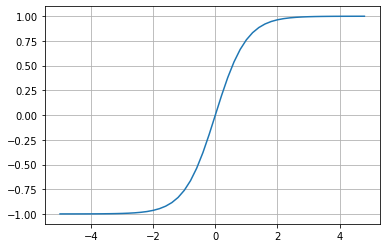

In [27]:
# tanh 激活函数
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [28]:
o.grad = 1.0
n.grad = 1 - o.data**2 # o = tanh(n); do/dn = 1 - tanh(n)**2 = 1 - o**2

# 加法操作在求导时只是将梯度直接分发传递
b.grad = n.grad
x1w1x2w2.grad = n.grad
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

# 我们只需要权重的导数
x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data

In [29]:
print(f"do/do = {o.grad:.3f}")
print(f"do/dn = {n.grad:.3f}")
print(f"do/db = {b.grad:.3f}")
print(f"do/d(x1w1 + x2w2) = {x1w1x2w2.grad:.3f}")
print(f"do/d(x1w1) = {x1w1.grad:.3f}")
print(f"do/d(x2w2) = {x2w2.grad:.3f}")
print(f"do/x2 = {x2.grad:.3f}")
print(f"do/w2 = {w2.grad:.3f}")
print(f"do/x1 = {x1.grad:.3f}")
print(f"do/w1 = {w1.grad:.3f}")

do/do = 1.000
do/dn = 0.500
do/db = 0.500
do/d(x1w1 + x2w2) = 0.500
do/d(x1w1) = 0.500
do/d(x2w2) = 0.500
do/x2 = 0.500
do/w2 = 0.000
do/x1 = -1.500
do/w1 = 1.000


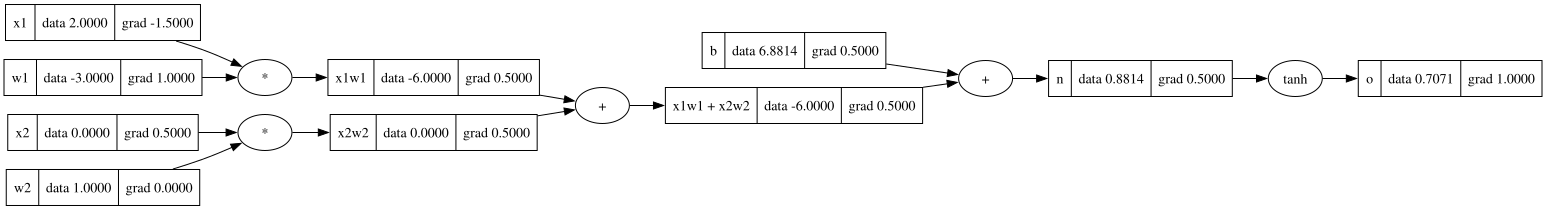

In [30]:
draw_dot(o)

现在，我们已经掌握了反向传播的计算原理。然而，对于拥有数十亿甚至上万亿参数的高度复杂神经网络（如 Transformer），我们显然不可能手动设置每个参数的梯度。我们需要一个自动化引擎来帮我们完成这项工作。


-------------
<br><br>
# 5. Micrograd: 为每个运算实现 Backward 反向求导函数<a id="5"></a>
-----------------
我们将为后续使用到的所有数学运算添加 `_backward` 函数。在执行每个运算时，我们将闭包保存求导逻辑，并将梯度反向传递给其前驱子节点。

让我们通过一个具体的例子来观察 `_backward` 函数是如何运作的。


In [31]:
# 输入 x1, x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# 权重 w1, w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# 神经元的偏置
b = Value(6.8813735870195432,label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh() 
o.label = 'o'

In [32]:
o.grad = 1.0           # do/do（初始化为 1，与数学导数一致）

o._backward()          #do/dn
n._backward()          #do/db = do/d(x1w1+x2w2)
b._backward()          # b 是叶子节点，因此没有 _backward() 函数
x1w1x2w2._backward()   #do/d(x1w1) = do/d(x2w2)
x2w2._backward()       #do/d(x2), do/d(w2)
x1w1._backward()       #do/d(x1), do/d(w1)
# x1, w1, x2, w2 是叶子节点，因此它们没有 _backward() 函数

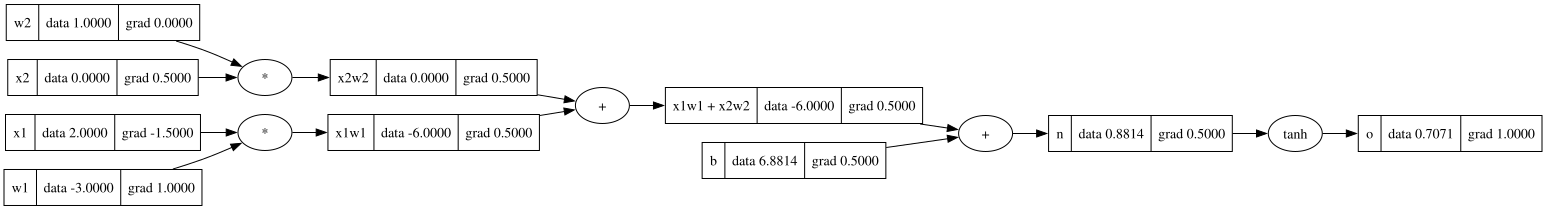

In [33]:
draw_dot(o)

请注意，我们需要手动设置 `o.grad = 1.0`。为什么？因为计算图中每个节点的初始占位梯度值均为 0。`_backward` 函数总是依赖于计算图中后继节点传回的梯度，如果起点输出的梯度是 0，那么所有节点的梯度计算结果都将变为 0（仔细想想其中的原理）。

但是，我们必须手动逐个调用 `_backward` 函数吗？当然不用！我们可以使用循环来遍历节点，但需要注意：我们必须按照特定的顺序来遍历这些节点。我们不能在某个节点的前驱节点梯度尚未计算完毕之前就调用它的 `_backward`。为此，我们需要借助一种称为“拓扑排序”的算法。

要计算神经网络中某个节点的梯度，必须先计算出依赖于它的所有后继节点的梯度。这可以通过**拓扑排序 (Topological Sort)** 来实现。拓扑排序是图结构的一种线性排列，使得所有有向边都严格从左指向右（L-R）。在计算机科学中，有向无环图 **(DAG)** 的[拓扑排序](https://en.wikipedia.org/wiki/Topological_sorting)是其顶点的线性排序，使得对于从**顶点 U** 到**顶点 V** 的每条**有向边 UV**，在排序中 <u>**U** 都排在 **V** 之前</u>。通常情况下，**包含环路的图 (Cyclic Graphs)** <u>不存在合法的拓扑排序。</u>


<a id="a3"></a>
![拓扑排序](_imgs/topological_sort.png)

**图 3. 拓扑排序示意图。** ([来源](https://medium.com/@konduruharish/topological-sort-in-typescript-and-c-6d5ecc4bad95))<br><br>


对于上图所示的有向图，DAG 的一种拓扑排序如下：
* A → B → C → D → G → F → E。

简而言之，在线性排列所有顶点时，拓扑序中绝不会存在指向前面的回指边。
到目前为止，在 `Value` 类中，我们为各个数学运算定义了各自的 `_backward` 方法。每个运算只能将流动的梯度反向传递给它的直接子节点。
现在，我们可以在 `Value` 类中创建一个全局的 `backward` 方法，该方法通过内部局部的 `build_topo` 函数利用拓扑排序来遍历 DAG（构建的表达式图）中的所有数学运算节点，从而在整个计算图上完成自动反向传播。该函数的工作流程如下：

- 使用 `build_topo` 将 DAG 按照拓扑顺序排序
- 存储拓扑排序后的节点列表
- 将最后一个节点（最终输出）的 `grad` 显式设置为 1.0
- 按照拓扑排序列表的**逆序**（反向传播：链式求导）进行遍历，并依次调用每个运算节点的 `_backward` 方法。


In [34]:
# 输入 x1, x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# 权重 w1, w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# 神经元的偏置
b = Value(6.8813735870195432,label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh() 
o.label = 'o'

In [35]:
o.backward()

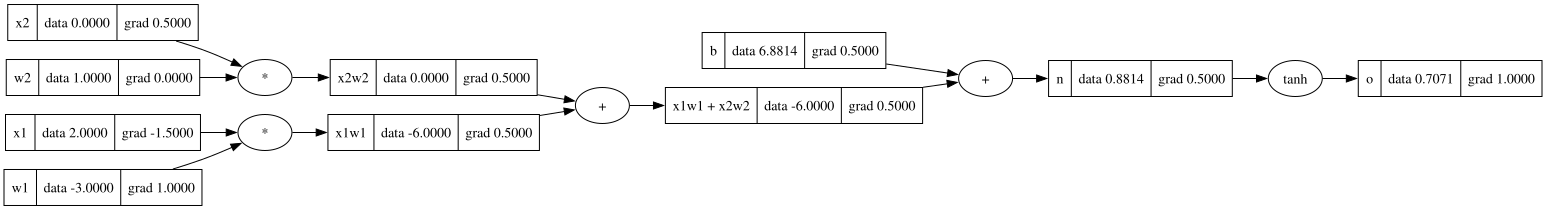

In [36]:
draw_dot(o)

-------------
<br><br>
# 6. Micrograd: 修复同一个节点被多次使用时的反向传播 Bug<a id="6"></a>
-----------------

在我们最初的 `Value` 实现中，当 DAG 中的某个变量/节点被多次使用时就会产生 Bug。让我们看下面的示例：

<u>注意：</u>由于上面的代码单元格中已经更新了 `Value` 类的实现，因此在 `Value` 类被更新为支持**梯度累加**之后，重新运行本 Notebook 时下面的示例会直接输出正确结果。此处的说明是为了展示在更新 `Value` 类之前存在的初始 Bug 问题。


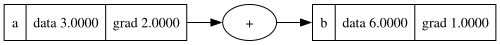

In [37]:
a = Value(3.0, label = 'a')
b = a + a ; b.label ='b'
b.backward()
draw_dot(b)

在上述代码单元格中，b 关于 a 的导数（`a.grad` 或 `db/da`）本应是 2，但上面的初始计算结果却是 1，这是错误的。这是因为我们只是简单地将输出的梯度覆盖写入了输入。由于传入了两次同一个输入对象，梯度计算覆盖了前一次的结果，忽略了同一输入对象的第二个分支实例。**除非我们修复这个 Bug，否则只要一个变量被使用超过一次，我们就会得到错误的梯度结果。**


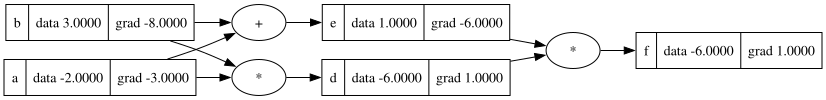

In [38]:
a = Value(-2.0,label='a')
b = Value(3.0,label='b')


d = a * b   ; d.label ='d'
e = a + b   ; e.label = 'e'
f = d * e   ; f.label='f'

f.backward()

draw_dot(f)

----------
<br><br>
## 6.1. 多元微积分链式法则<a id="601"></a>
-----
解决方案是：当我们从输出向每个参数节点反向传播时，梯度必须进行**累加 (accumulated)**。这来源于微积分中的[**多元复合函数链式法则 (Multivariate Chain Rule)**](https://en.wikipedia.org/wiki/Chain_rule#Example)。下面给出一个[具体示例](https://machinelearningmastery.com/the-chain-rule-of-calculus-even-more-functions/)：<br><br>
$$
h=g(r,s,t)=r^2-rs+t^3 \
r = x \cos y \ s = xe^y \ t = x+y \
$$

<a id="c3"></a>
由于我们处理的是多个自变量，在此应用链式法则需要计算偏导数。此外，$r$、$s$ 和 $t$ 作为中间变量。分别针对各个输入变量定义的求导公式如下：
![多元链式法则](_imgs/multivariate_chain_rule.png)

从这些公式可以看出，我们现在需要求解 9 个不同的偏导数。接着，我们将这些项分别代入 $\partial h/\partial x$ 和 $\partial h/\partial y$ 的表达式中：
![多元链式法则1](_imgs/multivariate_chain_rule1.png)

随后代入 $r$、$s$ 和 $t$ 的具体函数来求解导数：
![多元链式法则2](_imgs/multivariate_chain_rule2.png)

进一步化简（提示：利用三角恒等式 $2\sin y\cos y=\sin 2y$ 来化简 $\partial h/\partial y$）：
![多元链式法则3](_imgs/multivariate_chain_rule3.png)<br><br>


在反向传播中，某个节点的总梯度是通过累加计算得到的 —— 所有计算分支的影响都会相加。在 `Value` 类对象中，我们在 `__add__`、`__mul__` 和 `tanh` 等函数的局部 `_backward` 方法中将 `=` 替换为 `+=`（例如 `self.grad += ...` 和 `other.grad += ...`），以反映多元链式法则所要求的梯度累加机制。现在，我们在下面的示例中就能得到**完全正确的梯度计算结果**。


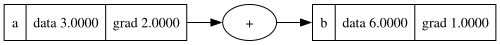

In [39]:
a = Value(3.0, label = 'a')
b = a + a ; b.label ='b'
b.backward()
draw_dot(b)

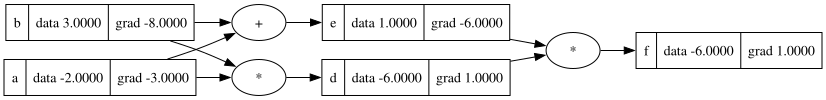

In [40]:
a = Value(-2.0,label='a')
b = Value(3.0,label='b')


d = a * b   ; d.label ='d'
e = a + b   ; e.label = 'e'
f = d * e   ; f.label='f'

f.backward()

draw_dot(f)

-------------
<br><br>
# 7. Micrograd: 添加更多数学运算<a id="7"></a>
-----------------

现在让我们通过添加更多功能和运算来进一步完善我们的 `Value` 类对象。新增的运算包括 `__rmul__`、`__pow__`、`__truediv__`、`__neg__`、`__sub__`、`exp` 以及其他所需的运算符。<br><br>
此外，我们可以通过在 `__add__` 函数中加入以下这行代码（将普通数值包装为 `Value` 对象）：`other = other if isinstance(other, Value) else Value(other)`，从而支持像 **a + 1** 这样的常数混合运算。<br><br>
我们还可以通过定义 `__radd__` 运算符来支持形如 **1 + a** 的逆向加法，避免 Python 在默认调用 `__add__`（即 `1.__add__(a)`）时因不识别用户自定义的 `Value` 对象而报错。如果 Python 调用 `__add__` 失败且存在 `__radd__`，它会交换操作数顺序并调用 `__radd__`。因此，**1 + a** 会转化为 **a + 1** 并成功执行。同样的逻辑也适用于 `__mul__` 和 `__rmul__`。


In [41]:
a = Value(2.0)
b = Value(4.0)
a+1

Value(data=3.0, grad=0.0)

In [42]:
a*1

Value(data=2.0, grad=0.0)

In [43]:
2*a

Value(data=4.0, grad=0.0)

In [44]:
a.exp()

Value(data=7.38905609893065, grad=0.0)

In [45]:
a/b

Value(data=0.5, grad=0.0)

In [46]:
a * 1/b

Value(data=0.5, grad=0.0)

In [47]:
a * (b**-1)

Value(data=0.5, grad=0.0)

In [48]:
a-b

Value(data=-2.0, grad=0.0)

In [49]:
# 输入 x1, x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# 权重 w1, w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# 神经元的偏置
b = Value(6.8813735870195432,label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh() 
o.label = 'o'
o.backward()

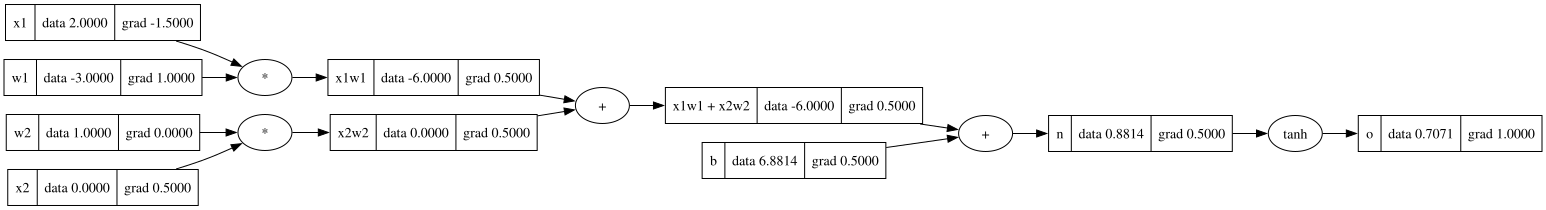

In [50]:
draw_dot(o)

-------------
<br><br>
## 7.1. 将 `tanh` 函数分解为其基本组成部分<a id="701"></a>
-----------------------------
目前，我们的 `Value` 类将 `tanh` 运算作为一个整体原子操作来实现。
现在，让我们将 `tanh` 函数拆解为一系列更基础的数学运算：加法、乘法、幂运算（取倒数/除法）以及指数运算（$e^x$）。

$$
	anh(x) = rac{e^{2x} - 1}{e^{2x} + 1}
$$

让我们将之前的神经元示例重新构建一遍，但这次使用复合基础运算代替原生的 `tanh` 算子。


In [51]:
# 输入 x1, x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# 权重 w1, w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# 神经元的偏置
b = Value(6.8813735870195432,label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
# -----------
e = (2*n).exp()
o = (e - 1)/(e + 1)
# ------------
o.label = 'o'
o.backward()

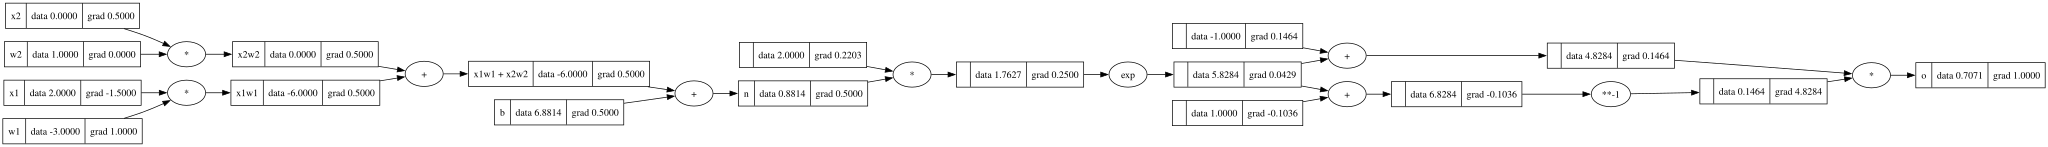

In [52]:
draw_dot(o)

<br><br>
# 8. Micrograd: 与 [`PyTorch`](https://pytorch.org/tutorials/) 的对比验证<a id="8"></a>
-----------------

我们可以使用 [**PyTorch**](https://pytorch.org/docs/stable/index.html) 来运行完全相同的单个神经元前向与反向传播计算，并对比两者计算出的梯度结果，以此验证我们的 Micrograd 引擎实现的正确性。

PyTorch 是一个开源的机器学习框架，可加速从研究原型到生产部署的过程。PyTorch 拥有类似于 NumPy 的 API，但增加了强大的 GPU 加速支持以及用于自动计算梯度的 Autograd 自动微分引擎。

在 Micrograd 中，我们处理的是**标量 (Scalars)**；而在 PyTorch 中，一切运算都建立在**张量 (Tensors)** 之上。张量本质上是标量组成的多维数组（矩阵、向量等）。PyTorch 的 Tensor 包含了数据、梯度以及用于反向传播的计算图追踪机制。


In [53]:
import sys
print(sys.executable)

/Users/CEO/anaconda3/envs/py36/bin/python


In [54]:
import torch

In [55]:
torch.Tensor([[1, 2, 3], [4, 5, 6]]),\
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape

(tensor([[1., 2., 3.],
         [4., 5., 6.]]),
 torch.Size([2, 3]))

In [56]:
torch.tensor([2.0]).dtype,\
torch.tensor([2.0]).double().dtype 

(torch.float32, torch.float64)

In [57]:
x1 = torch.tensor([2.0]).double()     ;x1.requires_grad=True
w1 = torch.tensor([-3.0]).double()    ;w1.requires_grad=True
x2 = torch.tensor([0.0]).double()     ;x2.requires_grad=True
w2 = torch.tensor([1.0]).double()     ;w2.requires_grad=True
b  = torch.tensor([6.8813735870195432]).double()     ;b.requires_grad=True
n = w1*x1 + w2*x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
-----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [58]:
o, o.item(), o.data.item()

(tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>),
 0.7071066904050358,
 0.7071066904050358)

-------------
<br><br>
# 9. Micrograd: 构建神经网络库（多层感知机 MLP）<a id="9"></a>
-----------------


## 9.1. [神经网络架构 (CS231n)](https://cs231n.github.io/neural-networks-1/)<a id="901"></a>
-------
### 按层组织的神经网络结构
-------
**作为计算图中神经元的神经网络**。神经网络被建模为神经元集合，这些神经元在有向无环图中相互连接。换句话说，某些神经元的输出可以成为其他神经元的输入。在常规的前馈神经网络中不允许存在环路（因为这会导致前向传播陷入无限循环）。神经网络模型通常被组织为互相独立的神经元层。对于常规神经网络，最常见的层类型是**全连接层 (Fully-Connected Layer)**，其中两个相邻层之间的神经元两两全部相连，但同一层内部的神经元之间没有任何连接。下面给出了两个示例神经网络拓扑结构，它们均采用了全连接层的组织形式：

<a id="a4"></a>
<p align="center">
    <img src="_imgs/2_layer_NN.png" width=360 height=240 align="left"> 
    <img src="_imgs/3_layer_NN.png" width=480 height=240 align="center"> 
</p>

**图 4. 从左至右：两个多层感知机（MLP）示意图：2 层神经网络（包含 1 个隐藏层，4 个神经元）与 3 层神经网络（包含 2 个隐藏层，每层 4 个神经元）。** ([来源](https://cs231n.github.io/neural-networks-1/))


<u>命名约定</u>：当我们说 $N$ 层神经网络时，我们**不计入输入层**。因此，单层神经网络仅由一个输入层和一个输出层组成（没有隐藏层）。在这层意义上，你有时可能会听到多层感知机（MLP）被称为“人工神经网络 (ANN)”或更通俗地称为“全连接层”。

<u>输出层</u>：与神经网络中的所有其他层不同，输出层神经元通常没有激活函数（或者说它们持有一个线性恒等传递函数）。这是因为最后的输出层通常被用于表示类别分数（例如在分类任务中）或者任意实数值目标（例如在回归任务中）。

<u>确定神经网络的规模</u>：用于衡量神经网络规模的两个最常用指标是**神经元数量**（更常指**参数数量**）。以上图中的两个网络为例：
- 左侧网络有 $4 + 2 = 6$ 个神经元（不含输入），权重数量为 $3 \times 4 + 4 \times 2 = 20$，偏置数量为 $4 + 2 = 6$，总共有 **26 个可学习参数**。
- 右侧网络有 $4 + 4 + 1 = 9$ 个神经元，权重数量为 $3 \times 4 + 4 \times 4 + 4 \times 1 = 32$，偏置数量为 $4 + 4 + 1 = 9$，总共有 **41 个可学习参数**。

作为对比，现代卷积神经网络（CNN）动辄包含数千万甚至上亿个参数，而大型语言模型（LLM，如 GPT-3 / GPT-4）则拥有数千亿甚至上万亿个参数。


现在让我们开发构建小型神经网络所需的组件机制。
首先，我们定义一个类来实现单个神经元 (`Neuron`)。接着我们构建神经网络层 (`Layer`)。最后，我们将各个层堆叠起来创建多层感知机 (`MLP`)。每个类的功能划分如下：

1. `Neuron` 类：用于创建单个神经元，包含一组权重 `w` 和一个偏置 `b`，并执行非线性激活函数。
2. `Layer` 类：用于创建一组平行的神经元，这一组神经元共享相同的输入维度。
3. `MLP` 类：用于将多个 `Layer` 串联堆叠在一起，形成一个深层神经网络结构。


In [59]:
import random

class Neuron:
    """ 定义单个神经元 """

    def __init__(self, nin):
        """ 为输入随机分配权重与偏置
        参数
        ----------
        nin: int
            神经元的输入特征维度
        """
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x): # w * x + b
        """ 计算神经元经过激活函数后的输出
        参数
        ----------
        x: list
            传入神经元的输入值列表

        返回
        ----------
        Value
            神经元的激活输出值
        """
        act = sum((wi*xi for wi, xi in zip(self.w, x)),  self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
    
class Layer:
    """ 定义神经元层 """

    def __init__(self, nin, nout):
        """ 初始化该神经元层
        参数
        ----------
        nin: int
            该层每个神经元的输入维度
        nout: int
            该层中神经元的数量
        """
        self.neurons = [Neuron(nin) for _ in range(nout)]
  
    def __call__(self, x):
        """ 计算该神经元层的输出
        参数
        ----------
        x: list
            输入特征列表

        返回
        ----------
        Value 或 list of Value
            神经元层的输出（单个输出或列表）
        """
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [param for neuron in self.neurons for param in neuron.parameters()]
    
    
class MLP:
    """ 定义多层感知机 (MLP) """
    
    def __init__(self, nin, nouts): # nouts 定义各层神经元数量列表
        """ 初始化多层感知机 (MLP)
        参数
        ----------
        nin: int
            MLP 的输入维度
        nouts: list
            包含各层神经元数量的列表
        """
        sz = [nin] + nouts
        self.layers= [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        """ 按顺序前向计算各层的输出
        参数
        ----------
        x: list
            传入 MLP 的输入列表

        返回
        ----------
        list 或 Value
            MLP 的最终输出
        """
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]


In [60]:
x = [2.0, 3.0]
a = Neuron(2)
a(x)

Value(data=0.9105848567129079, grad=0.0)

In [61]:
x = [2.0, 3.0]
b =  Layer(2, 3)
b(x)

[Value(data=0.9835475868478987, grad=0.0),
 Value(data=-0.18080027900666776, grad=0.0),
 Value(data=-0.36304820207442917, grad=0.0)]

In [62]:
# 神经网络的输入
x = [2.0, 3.0, -1.0]

# 实例化 MLP 模型
n = MLP(3, [4, 4, 1])

# 运行神经网络进行前向预测
n(x)

Value(data=-0.03132176728538012, grad=0.0)

In [63]:
len(n.parameters())

41

-----------
<br><br>
# 10. Micrograd: 创建微型数据集并编写损失函数<a id="10"></a>
-----------------
现在让我们创建一个微型数据集。我们拥有 4 个样本的**输入数据**以及对应的**目标标签**。


In [64]:
xs =[
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

# 目标真实标签（简单的二分类任务）
ys =[1.0, -1.0, -1.0, 1.0]

# 将所有输入送入神经网络计算预测值
# ypred = [n(x) for x in xs]
# ypred

<a id="c4"></a>
我们希望神经网络生成的预测值尽可能接近真实目标值。为此我们需要调整权重。但具体该如何调整呢？？？

- **反向传播！！！**

在此之前，我们需要通过一个单一数值来量化神经网络当前的预测表现有多差。这个衡量指标被称为**损失函数 (Loss Function)**。

在本例中，我们将使用**均方误差 (MSE, Mean Squared Error) 损失**：

$$
L = \sum_{i=1}^{n} (y_{\text{pred}, i} - y_{\text{true}, i})^2
$$


In [65]:
ypred = [n(x) for x in xs]
loss = 0
for ygt, yout in zip(ys, ypred):
    loss += (yout - ygt)**2 
print(loss)

Value(data=5.625114897319604, grad=0.0)


In [66]:
'''loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # ygt = 真实标签 (ground truth), yout = 模型输出 (output)
loss''' # 直接使用内置 sum 会因初始 int 0 + Value 导致类型运算问题

'loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # ygt = y_ground_truth, yout = y_output\nloss'

-----------
<br><br>
# 11. Micrograd: 神经网络参数<a id="11"></a>
-----------------
现在，我们计算了损失函数以及损失函数关于所有参数的梯度。然而，在当前的 `MLP` 实现中，这些梯度信息散落在计算图各个节点的 `grad` 属性中。

为了能够系统性地遍历并更新所有参数，我们需要在 `Neuron`、`Layer` 和 `MLP` 类中实现一个 `parameters()` 方法，该方法能够收集并返回该模块内部包含的所有 `Value` 参数对象。


In [67]:
n.layers[0].neurons[0].w[0].grad

0.0

In [68]:
n.layers[0].neurons[0].w[0].data

-0.3188397214186136

我们需要根据梯度信息来更新网络参数。**梯度**是一个指向损失函数**上升最快方向**的向量。因此，为了最小化损失，我们必须沿着梯度的**反方向**调整参数（即加上一个负的梯度步长）。

更新规则为：
$$
\text{parameter} \leftarrow \text{parameter} - \text{learning\_rate} \times \text{gradient}
$$
其中 `learning_rate`（学习率，步长）控制每次参数调整的幅度。


In [69]:
ypred = [n(x) for x in xs]
loss = 0
for ygt, yout in zip(ys, ypred):
    loss += (yout - ygt)**2 
print(loss)

Value(data=5.625114897319604, grad=0.0)


In [70]:
loss.backward()

In [71]:
for p in n.parameters():
    p.data += -0.05 * p.grad

In [72]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.5438762632690177, grad=0.0),
 Value(data=0.5956186061958746, grad=0.0),
 Value(data=-0.4498238385421293, grad=0.0),
 Value(data=0.5037095702051143, grad=0.0)]

-----------
<br><br><a id="12"></a>
# 12. Micrograd: 手动梯度下降优化与训练 MLP
-----------------

<a id="d3"></a><u>梯度下降 (Gradient Descent):</u><br>
现在，我们进入了神经网络训练中最核心的**梯度下降优化**环节。梯度下降是一种一阶迭代优化算法，用于寻找可微函数的局部最小值。

训练多层感知机（MLP）的完整步骤如下：
1. <u>前向传播 (Forward Pass)</u>：将输入数据输入到神经网络中，计算模型的预测输出，进而根据预测值与真实标签计算总损失。
2. <u>反向传播 (Backward Pass)</u>：将神经网络中所有参数的梯度清零，然后对总损失调用 `.backward()`，在计算图上自动反向传播误差并计算所有参数关于损失的梯度。
3. <u>参数更新 (Parameter Update)</u>：利用计算出的梯度信息，沿着负梯度方向更新 `MLP` 的所有参数（权重和偏置）。

 
训练神经网络的标准范式可以概括为：
1. 根据期望的网络架构实例化模型
2. 将输入数据传入模型得到预测值
3. 计算预测值与真实目标值之间的损失（Loss）
4. 调用反向传播方法计算所有参数的梯度
5. 调用优化步骤更新网络参数
6. 在多轮训练数据上重复步骤 2-5（**梯度下降优化迭代**）

除了像前一小节那样手动一步步执行之外，我们还可以编写一个简洁的 `train_MLP` 函数来为我们封装整个训练循环。


In [73]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.6041503111538816, grad=0.0)

In [74]:
xs =[
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

# 目标真实标签（简单的二分类任务）
ys =[1.0, -1.0, -1.0, 1.0] 

In [75]:
def train_MLP(n_iter=20, learning_rate=0.01):
    losses, steps = [], []
    step = 0
    for k in range(n_iter):
        step += 1
        steps.append(step)
        # 前向传播
        ypred = [n(x) for x in xs]
        loss = 0
        for ygt, yout in zip(ys, ypred):
            loss += (yout - ygt)**2 
        total_loss = loss
        losses.append(total_loss.data)

        # 反向传播 -> 将梯度清零，确保实际反向传播将损失导数累加到梯度中
        for p in n.parameters():
            p.grad = 0.0
        total_loss.backward()

        # 更新参数
        for p in n.parameters():
            p.data += -1 * learning_rate * p.grad

        print(k, total_loss.data)
    print(ypred)
    return [steps, losses]

In [76]:
_train_loss = train_MLP(40, 0.05)

0 5.485189247043687
1 3.3421234365691754
2 2.584049020397665
3 1.9610887856041734
4 1.4208451979993688
5 0.9652687705981344
6 0.6646346234265398
7 0.47428422790045377
8 0.3615123589435135
9 0.2870300719366895
10 0.23489049651030347
11 0.19691204612563087
12 0.16831557271479816
13 0.14617933935615032
14 0.12864178050918224
15 0.1144722088955907
16 0.10283027925617594
17 0.09312577909436154
18 0.08493384323191937
19 0.07794195214308396
20 0.071915798959111
21 0.066676715938482
22 0.06208638656923887
23 0.05803626867652136
24 0.0544401349246291
25 0.051228719740150565
26 0.048345816790658386
27 0.04574539276626418
28 0.043389424538740215
29 0.041246258705737185
30 0.03928935342896755
31 0.037496303502279935
32 0.03584807765559297
33 0.03432841658324537
34 0.032923353888887105
35 0.03162083189798568
36 0.03041039131962961
37 0.029282918859381307
38 0.028230440651596557
39 0.027245952177094315
[Value(data=0.9311099191634069, grad=-0.13778016167318619), Value(data=-0.9800438376407024, grad=0

In [77]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9322752068220904, grad=0.0),
 Value(data=-0.9804343270784147, grad=0.0),
 Value(data=-0.885414663220842, grad=0.0),
 Value(data=0.9093136457027569, grad=0.0)]

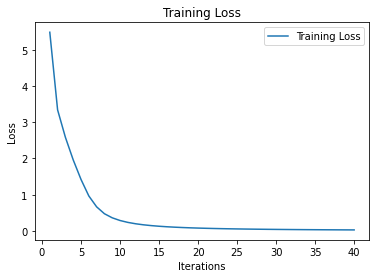

In [78]:
# 获取训练损失数值
train_values = _train_loss[1]
 
# 生成表示迭代轮数的整数序列
n_iter = _train_loss[0]
 
# 绘制训练损失曲线并添加图例标签
plt.plot(n_iter, train_values, label='Training Loss')
 
# 添加标题和坐标轴标签
plt.title('Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
 
# 设置坐标轴刻度
# plt.xticks(np.arange(0, 21, 2))
 
# 显示图表
plt.legend(loc='best')
plt.show()

在神经网络训练过程中，一个[极其常见的 Bug](https://twitter.com/karpathy/status/1013244313327681536?lang=en) 是<u>在迭代过程中忘记将计算图中参数的梯度信息清零</u>。请记住，当我们在计算图中计算梯度时，我们使用的是 `+=` 而不是 `=` 来累加梯度信息，因为计算图中的某个节点可能会被多次引用，为了得到该节点的正确总梯度，必须将所有分支贡献的梯度累加起来。

在上一节的手动实现中，如果在后续迭代中忘记清零梯度，梯度就会在后续前向传播（使用更新后的权重进行）中不断累加！这显然是错误的。因此，作为一个简单的修复，我们在每次调用 `.backward()` 之前，必须先将所有参数的梯度显式重置为 0（在 PyTorch 中对应 `.zero_grad()`）。


-----------
<br><br>
# 13. Micrograd: 总结<a id="13"></a>
-----------------


下面的总结归纳了本教程讨论的核心概念，涵盖了神经网络的基础知识及其训练流程。此外，从零构建并实现自动求导引擎 **Micrograd**，极大地帮助我们直观理解并巩固了神经网络与反向传播背后的基本原理。核心要点包括：


- **神经网络 (NNs)**： 

  - 神经网络是用于处理数据的数学计算表达式。

  - 它们由简单的基本数学运算复合而成。

  - 以多层感知机为例，它们接收输入数据以及权重和偏置参数。

- **前向传播与损失函数 (Forward Pass & Loss Function)**：

  - 前向传播是指将神经网络的数学表达式应用于输入数据以生成预测。

  - 随后通过评估损失函数来量化预测的准确程度。

  - 损失越低代表模型性能越好，即预测值与真实目标值越吻合。

- **反向传播与梯度下降 (Backpropagation & Gradient Descent)**：

  - 反向传播用于高效计算梯度，指明了每个参数对总损失的影响方向与大小。

  - 梯度指导我们如何调整各个参数以降低损失。

  - 梯度下降通过迭代更新参数来不断最小化损失函数。

- **表达能力与复杂性 (Power and Complexity)**：

  - 神经网络具有强大的拟合能力，能够解决高度复杂的非线性问题。

  - 现代网络可以拥有数十亿乃至数万亿个参数，构成庞大的计算网络。

  - 尽管结构庞大复杂，但它们依然遵循梯度下降与损失最小化这一相同的基础原理。

- **神经网络的涌现特性 (Emergent Properties)**：

  - 神经网络中的神经元在协同解决复杂问题时会展现出涌现特性。

  - 这些高级特性源自训练过程中网络内部神经元之间的相互作用。

- **在语言建模中的应用 (Application in Language Modeling)**：

  - 神经网络被广泛应用于语言建模任务中，例如预测序列中的下一个单词/Token。

  - 即便像 GPT 这样的大规模模型，其底层依然利用完全相同的神经网络训练基本原理。

  - 尽管模型规模更庞大、架构更精细，但核心仍然依赖梯度下降与损失最小化。

- **底层统一的基本原理 (Fundamental Principles)**：

  - 虽然具体工程实现多种多样，但神经网络训练的基本原理始终高度统一。

  - 实际应用中可能包含针对特定任务定制的各种梯度下降变体（如随机梯度下降 SGD、Adam 等）和不同损失函数（如交叉熵损失 Cross-Entropy Loss 等）。

  - 尽管存在这些变体，神经网络训练的核心思想与数学机制在各个领域都是通用的。

- **直观理解与实践构建 (Understanding and Implementation)**：

  - 通过透彻理解神经网络的底层基石原理，人们可以建立对其运作机制的深刻直觉。

  - 亲自动手探究并实现神经网络的底层细节，能够让人更好地理解并实现前沿深度学习概念。<br><br>


-----
<br><br><a id="r1"></a>
# 参考文献与拓展阅读
----
1. "<u>The spelled-out intro to neural networks and backpropagation: building micrograd</u>" [YouTube 视频教程](https://www.youtube.com/watch?v=VMj-3S1tku0)，2022年8月。
2. Andrej Karpathy **Micrograd** [GitHub 仓库](https://github.com/karpathy/micrograd)。
3. Andrej Karpathy **Neural Networks: Zero to Hero** [GitHub 仓库](https://github.com/karpathy/nn-zero-to-hero/tree/master)（配套视频教程的 [Notebook 代码](https://github.com/karpathy/nn-zero-to-hero/tree/master/lectures/micrograd)）。
4. Andrej Karpathy **Micrograd** 课后巩固[练习题](https://colab.research.google.com/drive/1FPTx1RXtBfc4MaTkf7viZZD4U2F9gtKN?usp=sharing)。
5. 文章: "<u>Backpropagation with Andrej Karpathy</u>" - Kavishka Abeywardana, 第 [1](https://medium.com/thedeephub/backpropagation-with-andrej-karpathy-part-1-916bc9bb54d8), [2](https://medium.com/thedeephub/backpropagation-with-andrej-karpathy-part-2-291a70069dd6), [3](https://medium.com/@kdwa2404/backpropagation-with-andrej-karpathy-part-3-717642087c34) 部分, 2024年2月。
6. "<u>Back(prop) to Basics — Fundamentals of Neural Networks</u>" - Elad Rapaport, [文章链接](https://medium.com/@erap129/back-prop-to-basics-fundamentals-of-neural-networks-d54cd8fc61e4), 2023年5月。
7. "<u>What is Perceptron: A Beginners Guide</u>" - Mayank Banoula, [文章链接](https://www.simplilearn.com/tutorials/deep-learning-tutorial/perceptron#:~:text=The%20perceptron%20model%20begins%20with,and%20is%20represented%20by%20'f.), 2023年5月。
8. "<u>What the Hell is Perceptron? The Fundamentals of Neural Networks</u>" - Sagar Sharma, [文章链接](https://towardsdatascience.com/what-the-hell-is-perceptron-626217814f53), 2017年9月。
9. "<u>Topological Sort: In Typescript and C#</u>" - Harish Reddy Konduru, [文章链接](https://medium.com/@konduruharish/topological-sort-in-typescript-and-c-6d5ecc4bad95), 2020年6月。
10. "<u>Automatic Differentiation Part 2: Implementation Using Micrograd</u>" - Aritra Roy Gosthipaty & Ritwik Raha, [文章链接](https://pyimagesearch.com/2022/12/26/automatic-differentiation-part-2-implementation-using-micrograd/), 2022年12月。
11. "<u>The Chain Rule of Calculus – Even More Functions</u>" - Stefania Cristina, [文章链接](https://machinelearningmastery.com/the-chain-rule-of-calculus-even-more-functions/), 2022年3月。
12. CS231n 用于视觉识别的卷积神经网络 [课程主页](https://cs231n.github.io/)
13. CS231n "<u>Neural Networks Part 1: Setting up the Architecture</u>" [讲义链接](https://cs231n.github.io/neural-networks-1/)
14. 维基百科条目: [导数 (Derivative)](https://en.wikipedia.org/wiki/Derivative), [反向传播 (Backpropagation)](https://en.wikipedia.org/wiki/Backpropagation), [激活函数 (Activation function)](https://en.wikipedia.org/wiki/Activation_function), [拓扑排序 (Topological sorting)](https://en.wikipedia.org/wiki/Topological_sorting), [多元微积分链式法则 (Multivariate chain rule)](https://en.wikipedia.org/wiki/Chain_rule#Example), [梯度下降 (Gradient descent)](https://en.wikipedia.org/wiki/Gradient_descent)
15. PyTorch 官方文档 [链接](https://pytorch.org/docs/stable/index.html)。
16. OpenAI [ChatGPT](https://chat.openai.com/): 协助整理 [**第 13 节 Micrograd: 总结**](#13) 的笔记内容。
